# Experiments for Randers-Finsler HMC (FHMCCorrected)

Twin of `FHMCUnbiased2_bump_metric` using **`FHMCCorrected`**, which follows the corrected
*non-canonical* dynamics (Ma, Chen & Fox recipe) instead of the canonical Hamiltonian flow:

$$\dot x = f(x) = -Q(x)\,\nabla \tilde H(x) + \Gamma(x),\qquad
Q(x) = \begin{pmatrix} 0 & -C(x) \\ C(x)^\top & 0\end{pmatrix},\qquad
C(x) = I + \sigma\big(F^*_z(p)\big)\,\frac{\nabla_p \tau(z,p)\, p^\top}{F^*_z(p)^2}.$$

The exact flow preserves $e^{-\tilde H}$, its position block is the inverse Legendre transform
(geodesics with drift), and its Jacobian exactly cancels $\Delta\tilde H$, so the exact-flow MH
ratio is identically one. The trajectory is integrated with the **implicit midpoint** scheme and
the exact log-Jacobian of the discrete map enters the acceptance ratio.

Unlike the other FHMC samplers of this series, `FHMCCorrected` takes an **explicit target**;
to reproduce the ring density (the Busemann-Hausdorff volume baked into the metric) we pass
$\pi(z) = \sigma_{BH}(z) = \det G^*(z)^{-1/2}$, so that $U + \log\sigma_{BH}$ cancels in $\tilde H$.

In [46]:
import torch
from torch import Tensor
from geodesic_toolbox import FHMCCorrected, ImplicitRHMCSampler
from geodesic_toolbox.cometric import DualRandersMetrics, RandersBumpRotational
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from tqdm import tqdm
from scipy.stats import gaussian_kde
import warnings
from matplotlib import cm

torch.manual_seed(0)

## 1 - Definition of Randers Metric and target density

In [47]:
beta = 0.9

randers_metric = RandersBumpRotational(
    beta = beta
)
randers_cometric = DualRandersMetrics(randers_metric)


def bh_target(z: Tensor) -> Tensor:
    """Busemann-Hausdorff density sigma_BH(z) = det G*(z)^{-1/2}.

    This is the density the metric-only FHMC samplers target implicitly;
    passing it as the explicit target makes U + log sigma_BH cancel in
    H_tilde. slogdet (not cholesky) so off-ring states, where G* stops
    being positive-definite, are rejected per-sample instead of raising.
    """
    G_star = randers_cometric.G_star(z)
    _, logabsdet = torch.linalg.slogdet(G_star)
    return torch.exp(-0.5 * logabsdet)

### Plotting helpers

Shared *rosenbrock-style* illustration helpers: a `magma` log-det background with a faint white ω drift field, and a cyan→magenta scatter of the chain samples (coloured along the chain index).

In [48]:
# --- Shared rosenbrock-style illustration helpers ---
EPS = 1e-6
EXTENT = [-1.5, 1.5, -1.5, 1.5]

# cyan -> magenta gradient used to colour the chain samples along time
CHAIN_CMAP = LinearSegmentedColormap.from_list("cyan_magenta", ["#00e5ff", "#ff00d4"])


def _bump_background(metric, N=200):
    """log det G(z) of the base Riemannian metric on the [-1.5, 1.5]^2 grid."""
    x = torch.linspace(-1.5, 1.5, N)
    y = torch.linspace(-1.5, 1.5, N)
    xx, yy = torch.meshgrid(x, y, indexing="ij")
    pts = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1)
    with torch.no_grad():
        g_inv_diag = metric.base_cometric(pts.float())
        det_G = 1.0 / (g_inv_diag[:, 0] * g_inv_diag[:, 1] + EPS)
    return np.log(det_G.reshape(N, N).numpy() + EPS)


def _bump_ring_radius(metric, n=400):
    """Radius of the bump ring = argmax of the radial log-det profile."""
    rr = np.linspace(0.05, 1.5, n)
    probe = torch.tensor(np.stack([rr, np.zeros_like(rr)], axis=1), dtype=torch.float32)
    with torch.no_grad():
        g = metric.base_cometric(probe)
        ld = np.log(1.0 / (g[:, 0] * g[:, 1] + EPS).numpy() + EPS)
    return float(rr[np.argmax(ld)])


def _bump_quiver(metric, n_theta=40):
    """omega drift field sampled *on the ring* (tangential rotational drift)."""
    r = _bump_ring_radius(metric)
    theta = np.linspace(0, 2 * np.pi, n_theta, endpoint=False)
    pts = np.stack([r * np.cos(theta), r * np.sin(theta)], axis=1)
    with torch.no_grad():
        omega = metric.omega(torch.tensor(pts, dtype=torch.float32)).numpy()
    return pts, omega


LOG_DET_G = _bump_background(randers_metric)
_finite = LOG_DET_G[np.isfinite(LOG_DET_G)]
VMIN, VMAX = _finite.min(), _finite.max()
QUIVER_PTS, QUIVER_VECS = _bump_quiver(randers_metric)


def plot_bump_background(ax, show_quiver=False):
    """magma log-det background + black omega drift arrows on the ring."""
    ax.imshow(LOG_DET_G.T, origin="lower", extent=EXTENT, cmap="magma",
              vmin=VMIN, vmax=VMAX, zorder=0)
    if show_quiver:
        ax.quiver(QUIVER_PTS[:, 0], QUIVER_PTS[:, 1],
                  QUIVER_VECS[:, 0], QUIVER_VECS[:, 1],
                  color="black", alpha=0.5, zorder=2,
                  angles="xy", scale_units="xy", scale=5, width=0.005)
    ax.grid(True, linestyle=":", linewidth=0.5, color="white", alpha=0.2)
    ax.set_axisbelow(False)
    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")
    ax.set_xlim(EXTENT[0], EXTENT[1])
    ax.set_ylim(EXTENT[2], EXTENT[3])


def scatter_chain(ax, traj, s=1.5, alpha=0.85):
    """Scatter chain samples coloured cyan->magenta along the chain index.

    traj : array/tensor of shape (n_chains, n_steps, 2) or (n_steps, 2).
    """
    if isinstance(traj, torch.Tensor):
        traj = traj.detach().cpu().numpy()
    traj = np.asarray(traj)
    if traj.ndim == 2:
        traj = traj[None]
    colors = CHAIN_CMAP(np.linspace(0, 1, traj.shape[1]))
    for i in range(traj.shape[0]):
        ax.scatter(traj[i, :, 0], traj[i, :, 1], c=colors, s=s, alpha=alpha,
                   edgecolors="none", zorder=3)
    # start point
    ax.scatter(traj[0, 0, 0], traj[0, 0, 1], facecolor="white",
               edgecolor="black", linewidth=0.6, s=35, zorder=4)

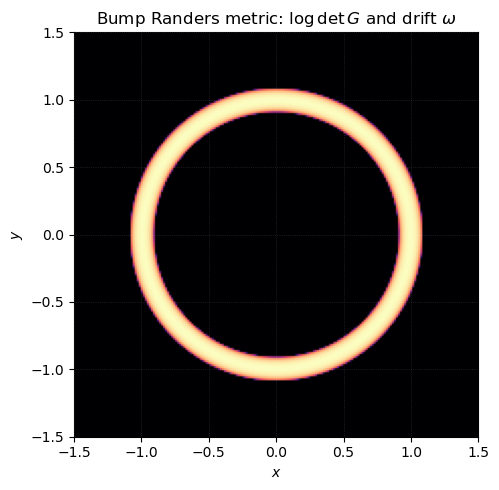

In [49]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_bump_background(ax)
ax.set_title(r"Bump Randers metric: $\log\det G$ and drift $\omega$")
plt.tight_layout()
plt.show()

## 2 - Trajectories of the corrected dynamics

A single deterministic trajectory of the corrected field $f$, integrated with the implicit
midpoint scheme. By Theorem 2 (pt. 3) the position block of $f$ is the inverse Legendre
transform, so the path is the Randers geodesic with rotational drift: it circulates around
the ring. The initial velocity is normalised to unit Finsler speed $F_z(v)=1$, the typical
scale of momenta drawn from $\pi(p|z)$ (for this metric that means $|v|\approx 16$).

In [50]:
l = 100
N_fx = 10
gamma = 0.002
N_run = 1

sampler = FHMCCorrected(
    bh_target,
    randers_cometric,
    l,
    N_fx,
    gamma,
    N_run,
    pbar = True,
    skip_acceptance = True,
    reg = 0.05,
    )

In [51]:
z_0 = torch.tensor([[0.,1.]])
v_0 = torch.tensor([[1., 0.]])
v_0 = v_0 / randers_metric(z_0, v_0)          # unit Finsler speed F(v)=1
p_0 = sampler.momentum_sampler.legendre(v_0, z_0)

x_0 = torch.cat([z_0, p_0], dim=-1)
traj_x, log_det = sampler.integrator(x_0, return_traj=True)
traj = traj_x[..., :2]                        # position block
print(f"log-Jacobian of the discrete map: {log_det.item():.3e}")

log-Jacobian of the discrete map: 4.408e-03


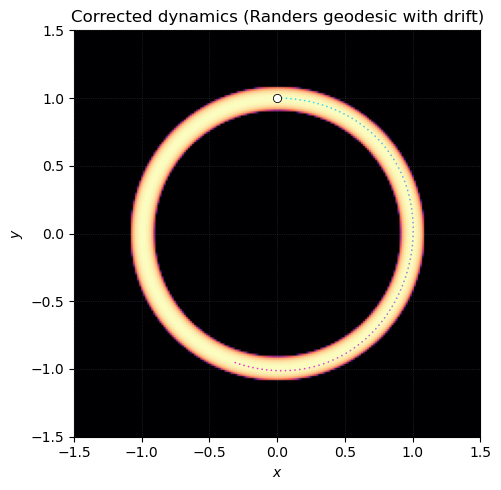

In [52]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_bump_background(ax)
scatter_chain(ax, traj[0])
ax.set_title("Corrected dynamics (Randers geodesic with drift)")
plt.tight_layout()
plt.show()

## 3 - Tests for FHMC algorithm with different acceptation rates

## 3.1. FHMC without rejection (or geodesic Random Walk)

In [53]:
l = 1
N_fx = 10
gamma = 0.001
N_run = 300

sampler = FHMCCorrected(
    bh_target,
    randers_cometric,
    l,
    N_fx,
    gamma,
    N_run,
    pbar = True,
    skip_acceptance = True,
    reg = 0.05,
    )

Initial momentum and velocity distribution

In [54]:
z_0 = torch.tensor([[0., 1.]]*10**4)

G_star = randers_cometric.G_star(z_0)[0,...]
w_star = randers_cometric.omega_star(z_0)[0,...]
p_0 = sampler.sample_momentum(z_0)
v_0 = sampler.momentum_sampler.reversed_legendre(p_0, z_0)

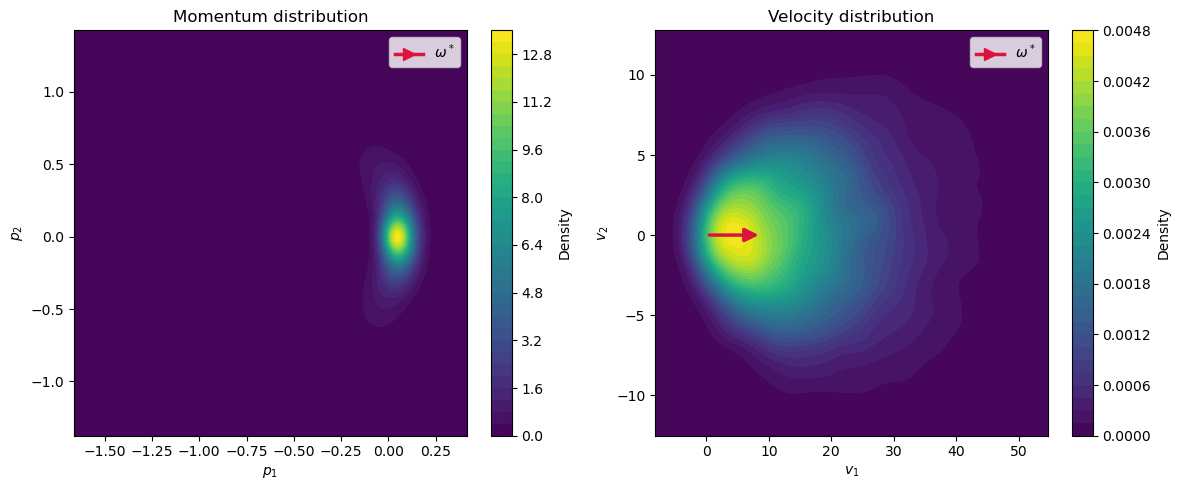

In [55]:
import matplotlib.lines as mlines

# Convert to numpy
p_np = p_0.detach().cpu().numpy()
v_np = v_0.detach().cpu().numpy()
w_np = w_star.detach().cpu().numpy()

# --- Auto-adapt bounds: 0.5–99.5 percentile + 15% margin ---
def auto_bounds(data, q_lo=0.5, q_hi=99.5, margin=0.15):
    lo = np.percentile(data, q_lo, axis=0)
    hi = np.percentile(data, q_hi, axis=0)
    span = hi - lo
    return lo - margin * span, hi + margin * span

p_lo, p_hi = auto_bounds(p_np)
v_lo, v_hi = auto_bounds(v_np)

grid_size = 150

def make_grid(lo, hi, n=grid_size):
    xx, yy = np.meshgrid(np.linspace(lo[0], hi[0], n), np.linspace(lo[1], hi[1], n))
    return xx, yy, np.vstack([xx.ravel(), yy.ravel()])

p_xx, p_yy, p_pts = make_grid(p_lo, p_hi)
v_xx, v_yy, v_pts = make_grid(v_lo, v_hi)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

def plot_panel(ax, data, xx, yy, pts, lo, hi, xlabel, ylabel, title, arrow_w):
    kde = gaussian_kde(data.T)
    zz = kde(pts).reshape(xx.shape)
    cf = ax.contourf(xx, yy, zz, levels=40, cmap="viridis")
    plt.colorbar(cf, ax=ax, label="Density")

    # Arrow scaled to 20% of the plot span, unit-direction normalised
    scale = 0.2 * np.mean(hi - lo) / (np.linalg.norm(arrow_w) + 1e-12)
    dx, dy = scale * arrow_w[0], scale * arrow_w[1]
    ax.annotate("", xy=(dx, dy), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color="crimson",
                                lw=2.5, mutation_scale=20))

    proxy = mlines.Line2D([], [], color="crimson", lw=2.5,
                          marker=">", markersize=9, label=r"$\omega^*$")
    ax.legend(handles=[proxy], loc="upper right", framealpha=0.8)
    ax.set_xlim(lo[0], hi[0])
    ax.set_ylim(lo[1], hi[1])
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

plot_panel(axs[0], p_np, p_xx, p_yy, p_pts, p_lo, p_hi,
           "$p_1$", "$p_2$", "Momentum distribution", w_np)
plot_panel(axs[1], v_np, v_xx, v_yy, v_pts, v_lo, v_hi,
           "$v_1$", "$v_2$", "Velocity distribution", w_np)

plt.tight_layout()
plt.show()

Full trajectories

In [56]:
n_traj = 10
traj = sampler.sample(
    z_0 = torch.tensor([[0., 1.]]*n_traj),
    return_traj= True, 
    progress=True
)

Sampling:   1%|          | 2/300 [00:00<00:55,  5.33steps/s, acceptance_rate=1]


_LinAlgError: linalg.cholesky: (Batch element 4): The factorization could not be completed because the input is not positive-definite (the leading minor of order 1 is not positive-definite).

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_bump_background(ax)
scatter_chain(ax, traj)
ax.set_title("FHMC without rejection (geodesic random walk)")
plt.tight_layout()
plt.show()

## 3.2. FHMC : acceptation ratio as likelihood ratio

With the corrected dynamics the acceptance ratio
$\alpha = \min\big(1, e^{\tilde H(x_0) - \tilde H(x_l)}\,|\det D\Psi(x_0)|\big)$
is close to one by construction (the exact flow gives exactly one): proposals that stay
in the valid region have $\alpha \approx 0.95$-$1$. The residual rejections are almost
entirely proposals whose trajectory leaves the narrow band around the ring where the
Randers condition holds ($G^*\succ 0$): those states give NaN energies and are rejected
per-sample. This bounds the usable integration time $\gamma\, l$, exactly as in the
`FHMCUnbiased2` twin. As in the other notebooks we compare the plain direction flip on
rejection with the *reduced* flip (Sohl-Dickstein 2012).

In [80]:
l = 1
N_fx = 10
gamma = 0.005
N_run = 30

sampler = FHMCCorrected(
    bh_target,
    randers_cometric,
    l,
    N_fx,
    gamma,
    N_run,
    pbar = True,
    reduced_flip = False,
    reg = 0.05,
    )

sampler_optimized = FHMCCorrected(
    bh_target,
    randers_cometric,
    l,
    N_fx,
    gamma,
    N_run,
    pbar = True,
    reg = 0.05,
    )

In [81]:
n_traj = 500

traj, acc, flip = sampler.sample(
    z_0 = torch.tensor([[0.,1.]]*n_traj),
    return_traj= True, 
    return_acceptance= True,
    progress = True,
    return_flip = True
)
print(f"Acceptance rate: {acc:.4f}")
print(f"Momentum flip rate: {flip:.4f}")

Sampling: 100%|██████████| 30/30 [00:10<00:00,  2.79steps/s, acceptance_rate=0.635]

Acceptance rate: 0.6352
Momentum flip rate: 0.3648


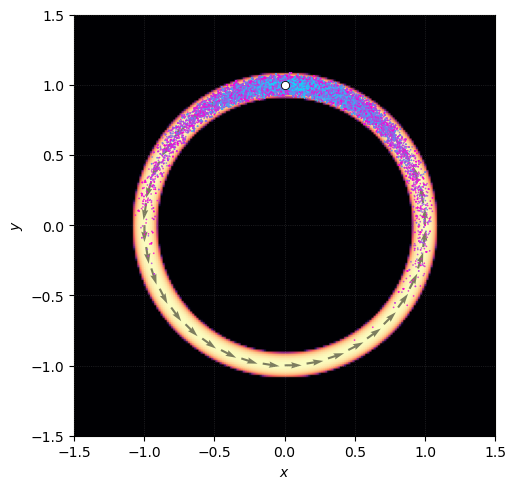

In [82]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_bump_background(ax, True)
scatter_chain(ax, traj)
plt.tight_layout()
plt.show()

In [83]:
n_traj = 500

traj, acc, flip = sampler_optimized.sample(
    z_0 = torch.tensor([[0.,1.]]*n_traj),
    return_traj= True, 
    return_acceptance= True,
    progress = True,
    return_flip = True
)
print(f"Acceptance rate: {acc:.4f}")
print(f"Momentum flip rate: {flip:.4f}")

Sampling: 100%|██████████| 30/30 [00:17<00:00,  1.71steps/s, acceptance_rate=0.613]

Acceptance rate: 0.6131
Momentum flip rate: 0.1744


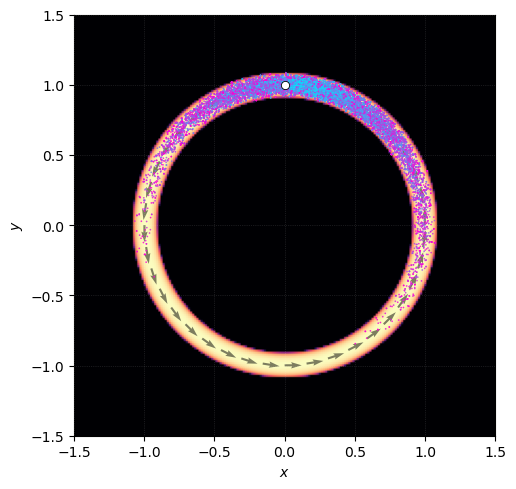

In [84]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_bump_background(ax, show_quiver = True)
scatter_chain(ax, traj)
plt.tight_layout()
plt.show()

## 4 - RHMC on the bump metric

Riemannian HMC baseline using the bump's base Riemannian metric (no Randers drift),
shown in the same style for comparison with the Finsler samplers above.

In [62]:
l = 1
N_fx = 6
gamma = 0.005
N_run = 30

rhmc_sampler = ImplicitRHMCSampler(
    randers_metric.base_cometric,
    l,
    N_fx,
    gamma,
    N_run,
    pbar=True,
)

In [63]:
n_traj = 100

traj_rhmc, acc_rhmc = rhmc_sampler.sample(
    z_0=torch.tensor([[0., 1.]] * n_traj),
    return_traj=True,
    return_acceptance=True,
    progress=True,
)
print(f"Acceptance rate: {acc_rhmc:.4f}")

Sampling: 100%|██████████| 30/30 [00:00<00:00, 110.58steps/s, acceptance_rate=0.979]

Acceptance rate: 0.9787


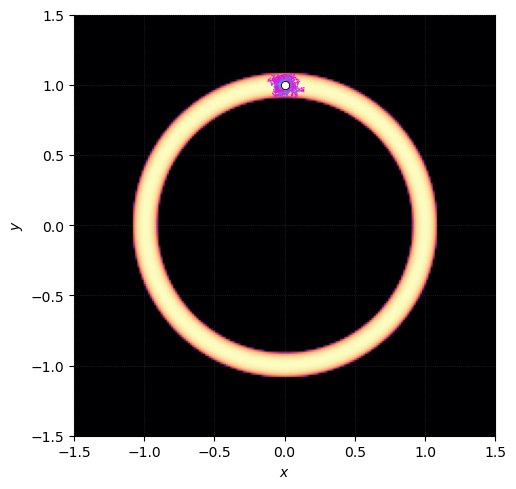

In [64]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_bump_background(ax)
scatter_chain(ax, traj_rhmc)
plt.tight_layout()
plt.show()